In [34]:
# make sure we can import from artifacts/cld.py and artifacts/plot_helpers.py
import sys
sys.path.append('../artifacts')
sys.path.append('../../thermoai/thermoai')

In [35]:
from dataclasses import dataclass
from typing import Callable, Union
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from diffrax import Euler, ItoMilstein, UnsafeBrownianPath
from jax import config, devices, jit
from jaxtyping import Scalar, Array, Float, Int
import jax.random as jr

from plot_helpers import plot_time_dependent_energy

from distributions import mog_energy as mog_energy_fn, sample_mog, mog_logpdf
from cld import CriticallyDampedLangevinDynamics

config.update("jax_enable_x64", True)

cpu_devices = devices("cpu")

script_key = jax.random.PRNGKey(0)


@dataclass
class CLDConfig(dict):
    state_dim: int
    beta: float
    M: float
    gamma: float
    Gamma: Union[float, None] = None
    U: Union[Callable, None] = None  # potential energy function
    V: Union[Callable, None] = None  # kinetic energy function
    score_fn: Union[Callable, None] = None  # score function

    def __post_init__(self):
        # Initialize the dict with the instance's attributes
        for key, value in self.__dict__.items():
            self[key] = value

    def __iter__(self):
        return iter(self.__dict__)

    def __getitem__(self, key):
        return self.__dict__[key]

In [51]:
# Create a time-dependent energy function
state_dim = 1
means = jnp.array([-3.0, 0.0])
covariances = 0.01*jnp.ones(2)
weights = jnp.array([0.8, 0.2])

# --- Make time-dependent covariances
T = 100.0
# T = 1.0
temp_final = 10.0
temp_fn = lambda t: temp_final #1+temp_final * t/T

params_fn = lambda t: {
    "means": means,
    "covariances": covariances*temp_fn(t),
    "weights": weights,
}


def sample_fwd_ics(key, N, t=0):
    x_key, v_key = jax.random.split(key, 2)
    x0s_keys = jax.random.split(x_key, N)
    v0s_keys = jax.random.split(v_key, N)
    x0s = jax.vmap(lambda key: sample_mog(key, **params_fn(t)))(x0s_keys)
    v0s = jax.vmap(lambda key: jr.normal(key))(v0s_keys)
    return x0s, v0s

def sample_bwd_ics(key, N, t=T):
    x_key, v_key = jax.random.split(key, 2)
    x0s_keys = jax.random.split(x_key, N)
    v0s_keys = jax.random.split(v_key, N)
    x0s = jax.vmap(lambda key: sample_mog(key, **params_fn(t)))(x0s_keys)
    v0s = jax.vmap(lambda key: jr.normal(key))(v0s_keys)
    return x0s, v0s


def U_x_t(x: Float, t_0_to_1: Float, t_fn: Callable = lambda t: t):
    """t_0_to_1 is the time input to the potential energy function.
    # t_fn is a function that maps the input time from 0 to 1, in some arbitrary way (e.g. nonlinear)
    # At time t=0, this function returns the energy of a 1D bimodal Gaussian
    # At time t=1, this function returns the energy of a 1D Normal"""
    return mog_energy_fn(x, **params_fn(t_fn(t_0_to_1)))


rev_U_x_t = lambda x, t: U_x_t(x, t, t_fn=lambda t: T - t)



In [52]:
# Create SDE terms
# NOTE: T is 1.0 in CLD paper.
fwd_time_config = CLDConfig(
    state_dim=state_dim,
    beta=1.0,  # This controls speed at which system equilibrates
    M=1.0,
    gamma=2.0,
    U=U_x_t,
)
bwd_time_config = CLDConfig(
    state_dim=state_dim,
    beta=1.0,  # This controls speed at which system equilibrates
    M=1.0,
    gamma=2.0,
    U=rev_U_x_t,  # Reverse potential energy landscape
)

fwd_cld = CriticallyDampedLangevinDynamics(**fwd_time_config)
bwd_cld = CriticallyDampedLangevinDynamics(**bwd_time_config)

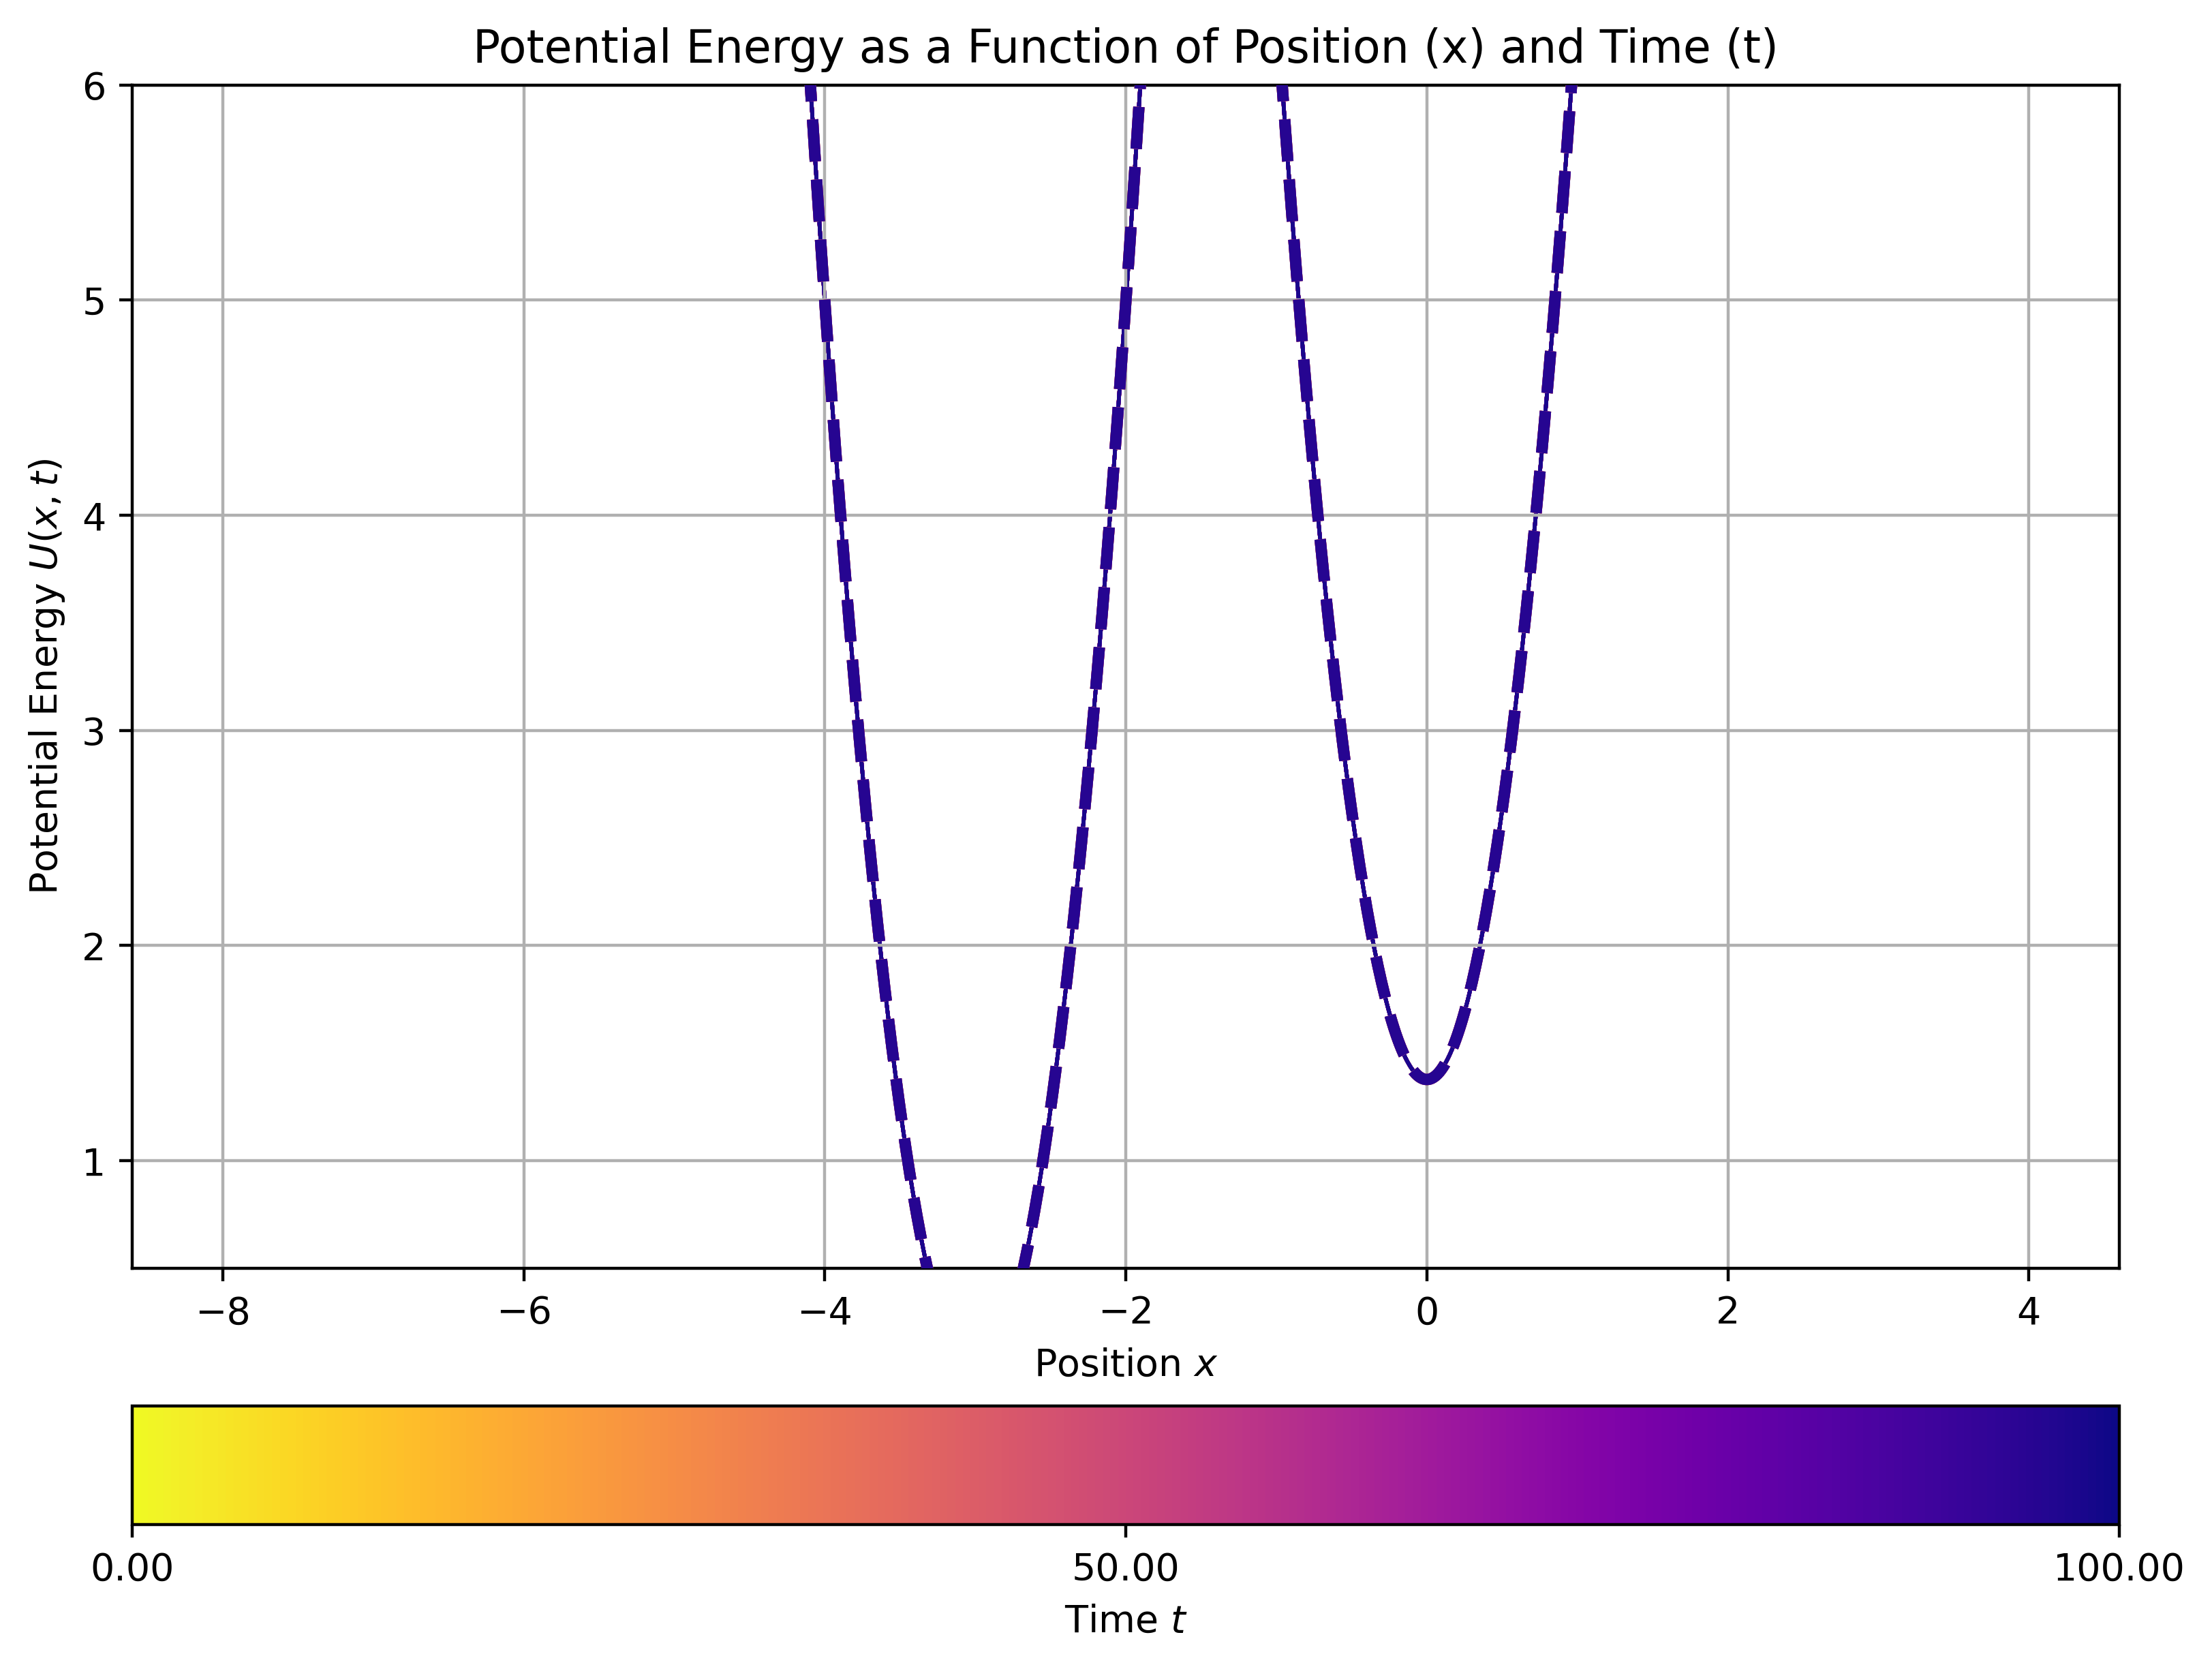

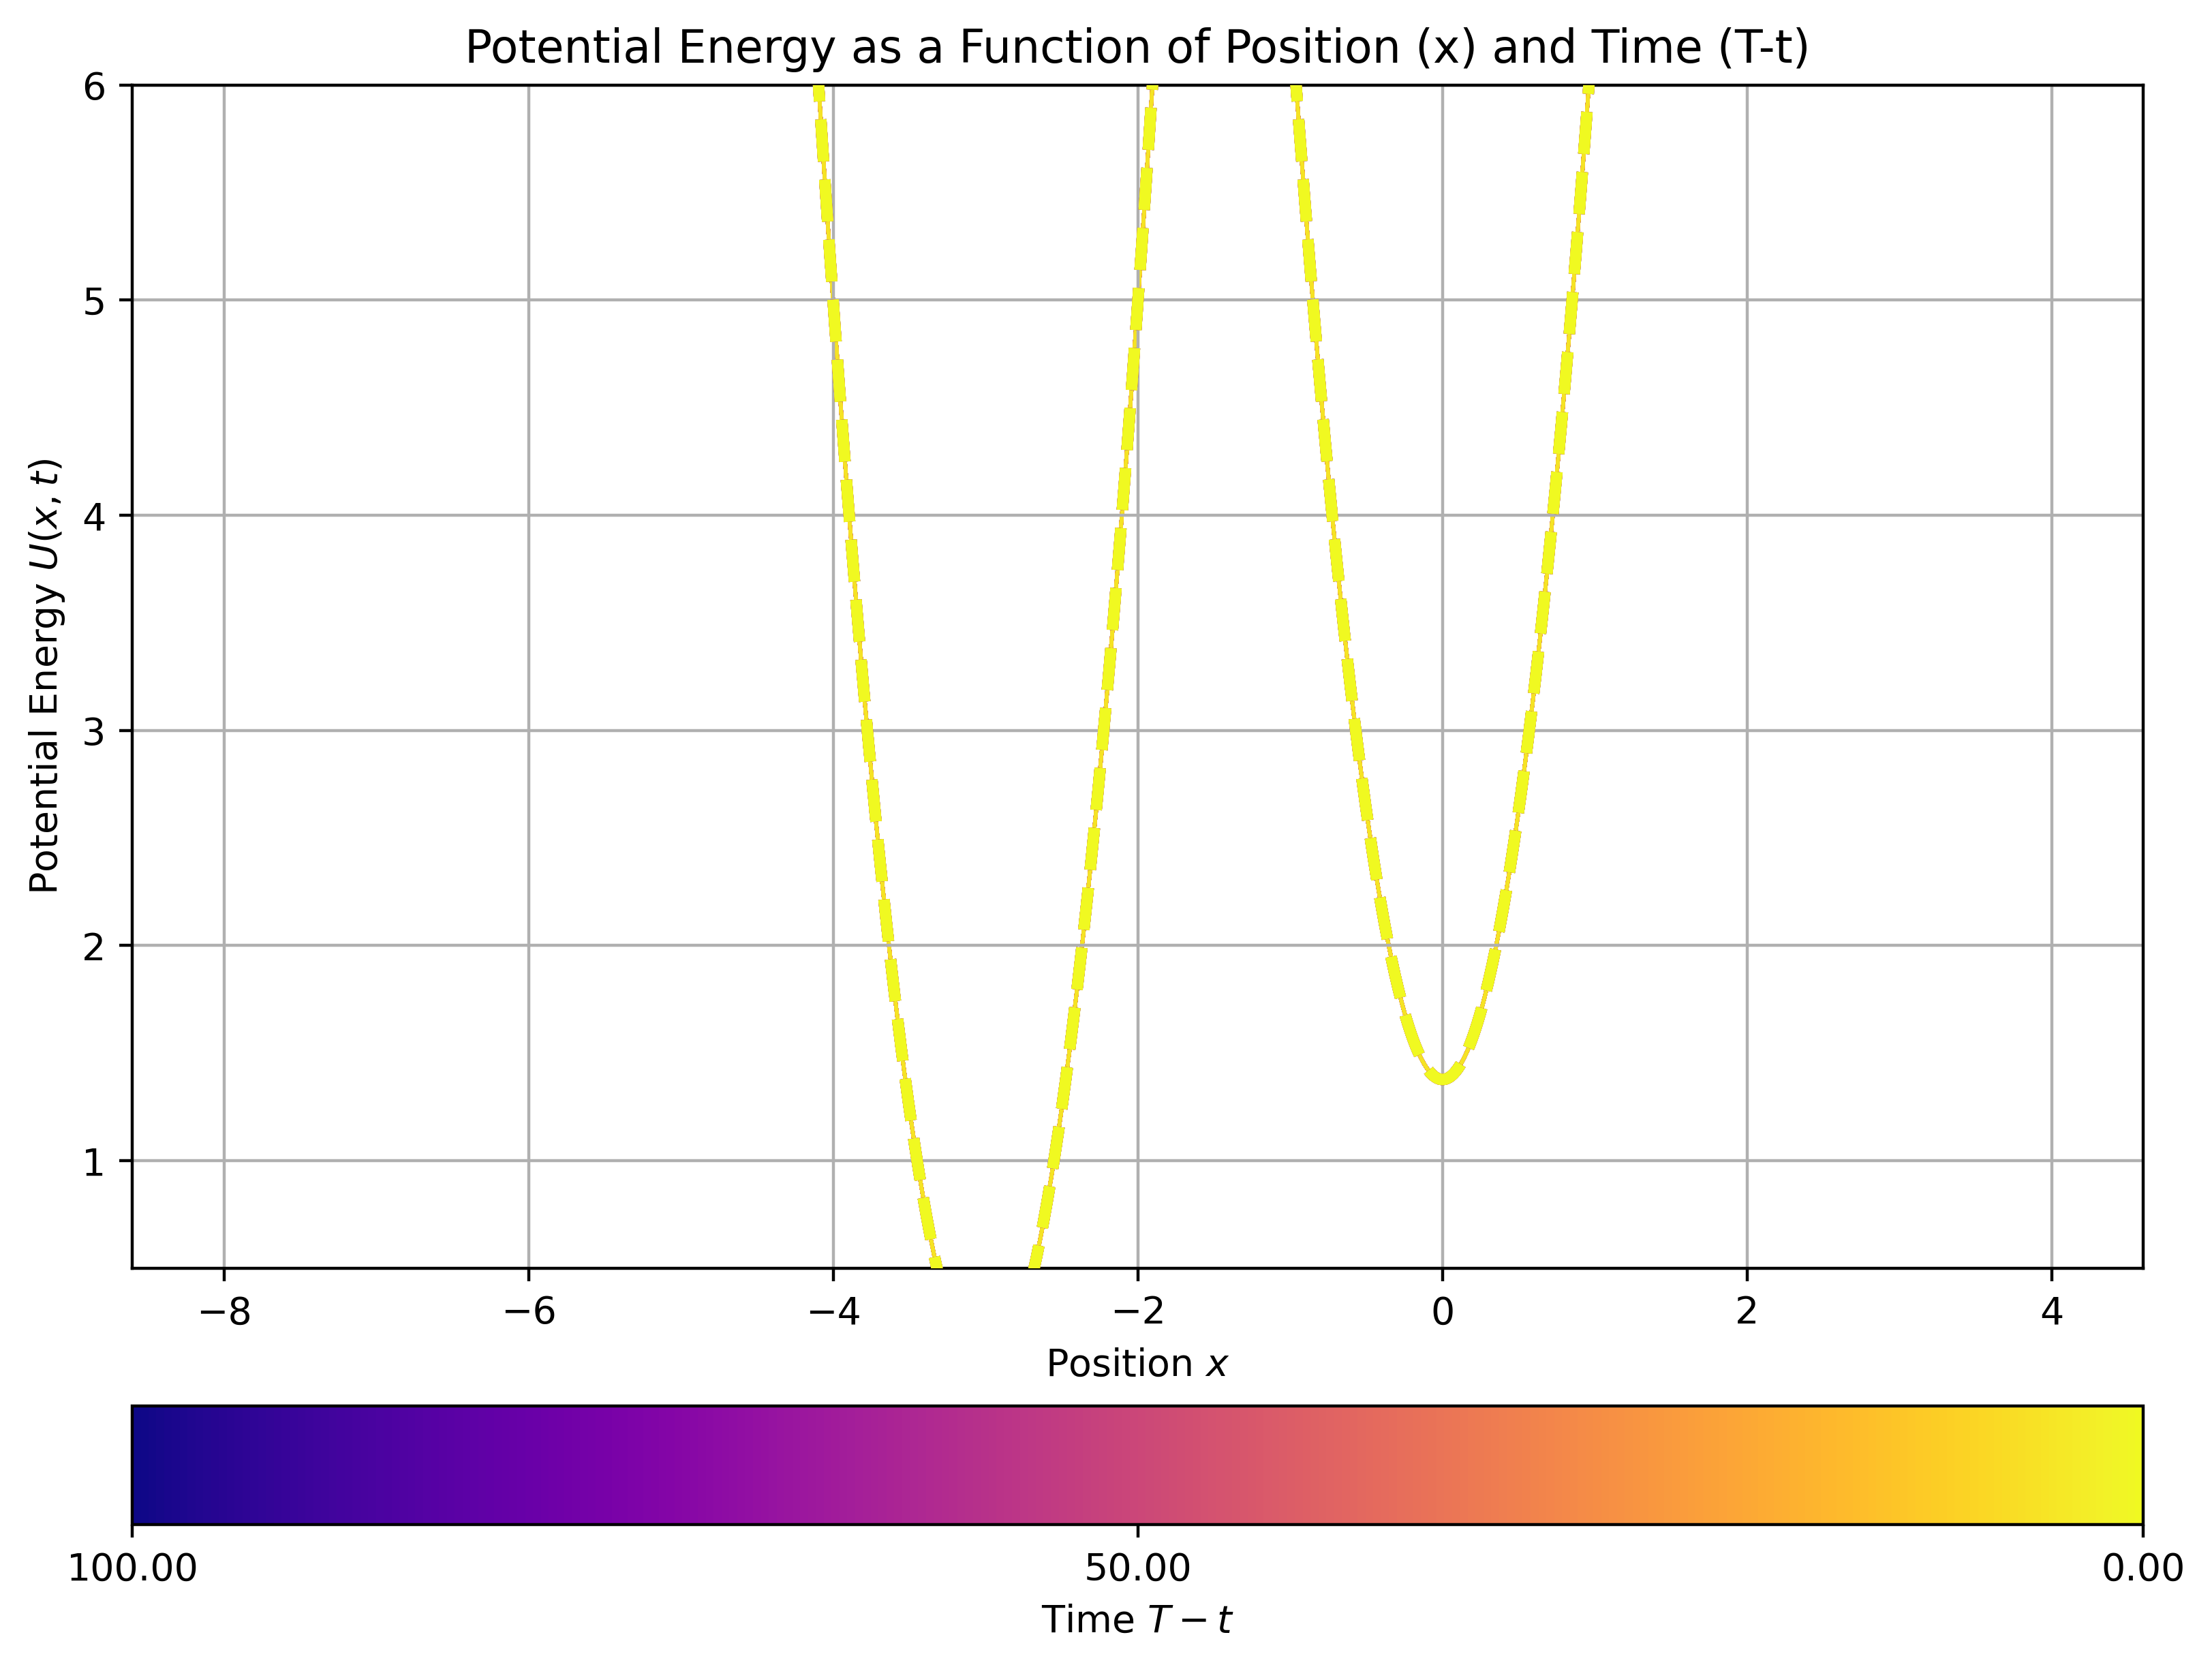

In [53]:
plot_time_dependent_energy(U_x_t, T=T)
plot_time_dependent_energy(rev_U_x_t, T=T, reverse=True)


In [54]:
# Set up solve parameters
solver = ItoMilstein()  # Trust in dt -> 0...


def _split_state(y):
    state_dim = fwd_cld.state_dim
    return y[:state_dim], y[state_dim:]


def solve_fwd(key, x0, v0, dt, t0=0.0, t1=1.0):
    """Solve (simulate) the forward diffusion process for a single trajectory.

    Example usage:

        # x0 = 0.0
        # v0 = 0.0
        # dt = 1e-5
        # t0, t1 = 0.0, 1.0

        # (x, v, t), (xTs, vTs) = solve_fwd(key, x0, v0, dt, t0, t1)
    """
    brownian = UnsafeBrownianPath(shape=(2 * fwd_cld.state_dim,), key=key)
    terms = fwd_cld.get_fwd_terms(brownian)

    @jax.jit
    def solve_step(carry, _):
        y, t = carry
        next_y = solver.step(terms, t, t + dt, y, None, None, made_jump=False)[0]
        return (next_y, t + dt), next_y

    (y, t), ys = jax.lax.scan(
        solve_step, (jnp.array([x0, v0]), t0), length=int((t1 - t0) / dt)
    )
    x, v = _split_state(y)
    xs, vs = jax.vmap(_split_state)(ys)
    return (x, v, t), (xs, vs)



# Example usage for sampling N trajectories in parallel:
N = 10000
dt = 1e-2
t0, t1 = 0.0, T
script_key, sample_key, solve_key = jax.random.split(script_key, 3)


# --- Solve N trajectories in parallel, with unique key, x0, v0.
x0s, v0s = sample_fwd_ics(sample_key, N, t=0)
solve_keys = jax.random.split(solve_key, N)
(xTs, vTs, ts), _ = jax.vmap(lambda key, x0, v0: solve_fwd(key, x0, v0, dt, t0, t1))(
    solve_keys, x0s, v0s
)


Mean of xTs: -2.410174429231282


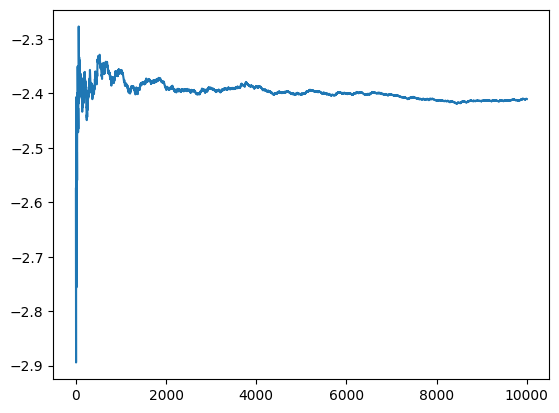

In [55]:
import numpy as np
xTs = np.array(xTs)
mean_xTs = np.mean(xTs)
print(f"Mean of xTs: {mean_xTs}")
# rolling mean
rolling_mean = np.cumsum(xTs, axis=0) / np.arange(1, N+1)[:, np.newaxis]
plt.plot(rolling_mean)
plt.show()



In [56]:
script_key, bwd_sample_key, bwd_solve_key = jax.random.split(script_key+1, 3)
x0s_bwd, v0s_bwd = sample_bwd_ics(bwd_sample_key, N, t=T)
mean_x0s_bwd = jnp.mean(x0s_bwd)
print(f"Mean of x0s_bwd: {mean_x0s_bwd}")


Mean of x0s_bwd: -2.403768027777723


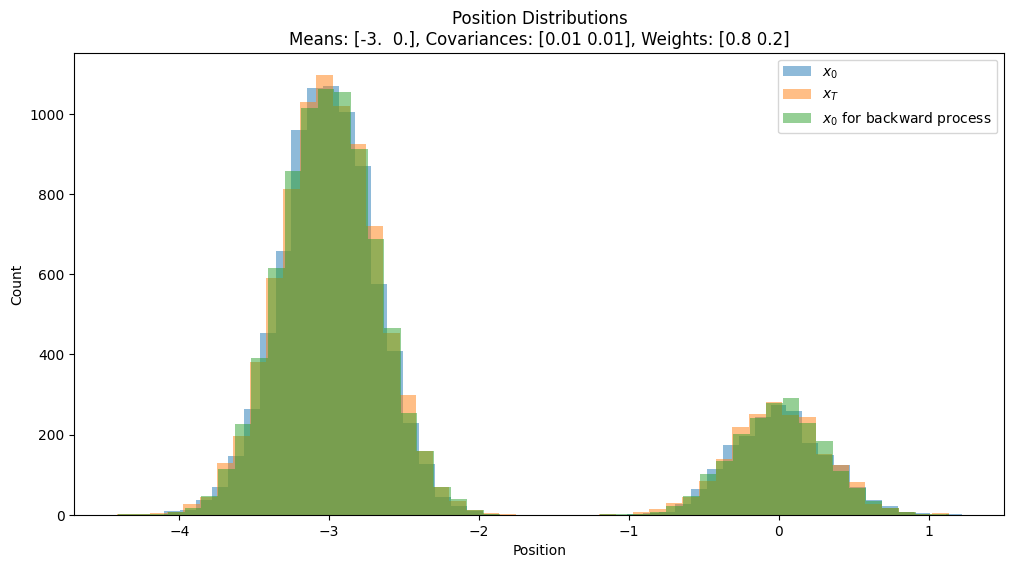

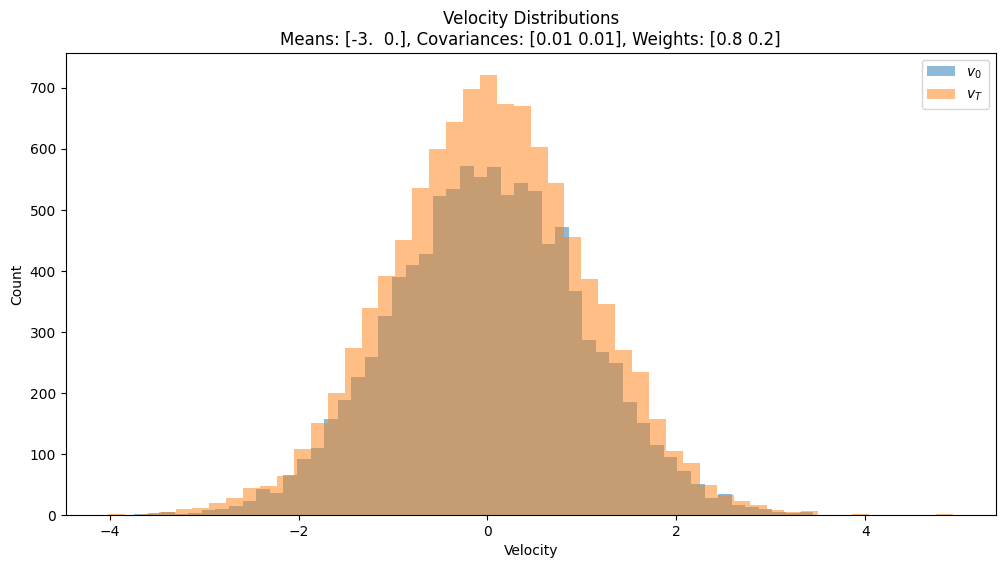

In [57]:
# --- Plot histograms of initial and final distributions.
plt.figure(figsize=(12, 6))
plt.hist(x0s, bins=50, alpha=0.5, label="$x_0$")
plt.hist(xTs, bins=50, alpha=0.5, label="$x_T$")
plt.hist(x0s_bwd, bins=50, alpha=0.5, label="$x_0$ for backward process")
plt.legend()
plt.title(f"Position Distributions\nMeans: {means}, Covariances: {covariances}, Weights: {weights}")
plt.xlabel("Position")
plt.ylabel("Count")
plt.show()

# v0
plt.figure(figsize=(12, 6))
plt.hist(v0s, bins=50, alpha=0.5, label="$v_0$")
plt.hist(vTs, bins=50, alpha=0.5, label="$v_T$")
plt.legend()
plt.title(f"Velocity Distributions\nMeans: {means}, Covariances: {covariances}, Weights: {weights}")
plt.xlabel("Velocity")
plt.ylabel("Count")
plt.show()

In [21]:
# Set up solve parameters
solver = Euler()  # Trust in dt -> 0...


def _split_state(y):
    state_dim = fwd_cld.state_dim
    return y[:state_dim], y[state_dim:]


def solve_bwd(key, x0, v0, dt, t0=0.0, t1=1):
    """Solve (simulate) the forward diffusion process for a single trajectory.

    Example usage:

        # x0 = 0.0
        # v0 = 0.0
        # dt = 1e-5
        # t0, t1 = 0.0, 1.0

        # (x, v, t), (xTs, vTs) = solve_fwd(key, x0, v0, dt, t0, t1)
    """
    brownian = UnsafeBrownianPath(shape=(2 * bwd_cld.state_dim,), key=key)
    terms = bwd_cld.get_fwd_terms(brownian)

    @jax.jit
    def solve_step(carry, _):
        y, t = carry
        next_y = solver.step(terms, t, t + dt, y, None, None, made_jump=False)[0]
        return (next_y, t + dt), next_y

    (y, t), ys = jax.lax.scan(
        solve_step, (jnp.array([x0, v0]), t0), length=int((t1 - t0) / dt)
    )
    x, v = _split_state(y)
    xs, vs = jax.vmap(_split_state)(ys)
    return (x, v, t), (xs, vs)



# Example usage for sampling N trajectories in parallel:
N = 1000
dt = 1e-2
t0, t1 = 0.0, T



# --- Solve N trajectories in parallel, with unique key, x0, v0.
solve_keys_bwd = jax.random.split(bwd_solve_key, N)
(xTs_bwd, vTs_bwd, ts), _ = jax.vmap(lambda key, x0, v0: solve_bwd(key, x0, v0, dt, t0, t1))(
    solve_keys_bwd, xTs.reshape(-1), vTs.reshape(-1)
)

# (
#     solve_keys_bwd, x0s_bwd, v0s_bwd
# )


ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * most axes (2 of them) had size 10000, e.g. axis 0 of argument x0 of type float64[10000];
  * one axis had size 1000: axis 0 of argument key of type uint32[1000,2]

In [ ]:
# --- Plot histograms of initial and final distributions.
plt.hist(x0s_bwd, bins=50, alpha=0.5, label="$x_0$")
plt.legend()
plt.hist(xTs, bins=50, alpha=0.5, label="$x_T$")
plt.legend()
plt.show()

In [ ]:
# --- Plot histograms of initial and final distributions.
plt.hist(x0s_bwd, bins=50, alpha=0.5, label="$x_T$")
plt.legend()
plt.hist(xTs_bwd, bins=50, alpha=0.5, label="$xbwd_0$")
plt.legend()
plt.hist(x0s, bins=50, alpha=0.5, label="$x_0$")
plt.legend()
plt.show()

# v0
plt.hist(v0s_bwd, bins=50, alpha=0.5, label="$v_0$")
plt.legend()
plt.hist(vTs_bwd, bins=50, alpha=0.5, label="$v_T$")
plt.legend()
plt.show()